In [1]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import ast
import os


In [1]:
DATA_DIR = "../Dataset/"

with open(f"{DATA_DIR}release_conditions.json", "r", encoding="utf-8") as f:
    conditions = json.load(f)

with open(f"{DATA_DIR}release_evidences.json", "r", encoding="utf-8") as f:
    evidences = json.load(f)

print(f"   Діагнозів: {len(conditions)}")
print(f"   Симптомів/антецедентів: {len(evidences)}")


NameError: name 'json' is not defined

In [3]:
# Ключові слова для виявлення процедурних/тестових вузлів
PROCEDURE_KEYWORDS = [
    "x-ray", "scan", "mri", "ct ", "blood test", "blood count",
    "ecg", "ekg", "ultrasound", "biopsy", "culture", "spirometry",
    "oxygen", "spo2", "saturation", "troponin", "d-dimer", "crp",
    "measure", "level", "rate", "pressure", "temperature", "pulse",
    "swab", "urine", "stool", "smear", "angiography",
]

symptom_names = {}
procedure_codes = set()  # коди симптомів, що є процедурами або обстеженнями

for code, info in evidences.items():
    question = info.get("question_en", "")

    if question:
        label = (question
                 .replace("Do you have ", "")
                 .replace("Have you had ", "")
                 .replace("Are you ", "")
                 .replace("Did you ", "")
                 .replace("Is there ", "")
                 .replace("Do you ", "")
                 .replace("Have you ", "")
                 .rstrip("?")
                 .strip())
        if len(label) > 50:
            label = label[:47] + "..."
        symptom_names[code] = label

        # Перевіряємо, чи вузол схожий на процедуру/обстеження
        if any(kw in question.lower() for kw in PROCEDURE_KEYWORDS):
            procedure_codes.add(code)
    else:
        symptom_names[code] = code

print(f"   Словник побудовано: {len(symptom_names)} записів")
print(f"   Процедурних вузлів виявлено: {len(procedure_codes)}")
print("\nПриклади процедур:")
for code in list(procedure_codes)[:8]:
    print(f"  {code} → {symptom_names[code]}")


   Словник побудовано: 223 записів
   Процедурних вузлів виявлено: 15

Приклади процедур:
  E_40 → been in contact with someone who has had pertus...
  E_150 → been able to pass stools or gas since your symp...
  E_102 → consulting because you have high blood pressure
  E_188 → pale stools and dark urine
  E_41 → been in contact with a person with similar symp...
  E_30 → feel your abdomen is bloated or distended (swol...
  E_198 → work in agriculture
  E_73 → In the last month, have you been in contact wit...


In [4]:
G = nx.Graph()

for condition_name, cond_data in conditions.items():
    G.add_node(condition_name,
               node_type="diagnosis",
               severity=cond_data.get("severity", 0))

    for symptom_code in cond_data.get("symptoms", {}).keys():
        label = symptom_names.get(symptom_code, symptom_code)
        ntype = "procedure" if symptom_code in procedure_codes else "symptom"
        G.add_node(label, node_type=ntype, code=symptom_code)
        G.add_edge(condition_name, label, weight=1.0, edge_type=ntype)

    for ant_code in cond_data.get("antecedents", {}).keys():
        label = symptom_names.get(ant_code, ant_code)
        ntype = "procedure" if ant_code in procedure_codes else "antecedent"
        G.add_node(label, node_type=ntype, code=ant_code)
        G.add_edge(condition_name, label, weight=0.5, edge_type=ntype)

print(f"   Граф побудовано")
print(f"   Вузлів: {G.number_of_nodes()}")
print(f"   Ребер:  {G.number_of_edges()}")

proc_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "procedure"]
print(f"   Процедурних вузлів у графі: {len(proc_nodes)}")

first_diag = list(conditions.keys())[0]
print(f"\nПриклад вузлів для '{first_diag}':")
for n in list(G.neighbors(first_diag))[:5]:
    ntype = G.nodes[n].get("node_type", "?")
    print(f"  [{ntype}] → {n}")


   Граф побудовано
   Вузлів: 272
   Ребер:  888
   Процедурних вузлів у графі: 15

Приклад вузлів для 'Spontaneous pneumothorax':
  [symptom] → feel pain somewhere
  [symptom] → pain somewhere, related to your reason for cons...
  [symptom] → Does the pain radiate to another location
  [symptom] → Characterize your pain:
  [symptom] → How fast did the pain appear


In [5]:
train_path = f"{DATA_DIR}release_train_patients"

if os.path.exists(train_path + ".csv"):
    df = pd.read_csv(train_path + ".csv")
else:
    df = pd.read_csv(train_path)

print(f"   Пацієнтів завантажено: {len(df):,}")
print(f"   Колонки: {list(df.columns)}")
print(f"\nПерший рядок:")
print(df.iloc[0])


   Пацієнтів завантажено: 1,025,602
   Колонки: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']

Перший рядок:
AGE                                                                      18
DIFFERENTIAL_DIAGNOSIS    [['Bronchitis', 0.19171203430383882], ['Pneumo...
SEX                                                                       M
PATHOLOGY                                                              URTI
EVIDENCES                 ['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...
INITIAL_EVIDENCE                                                       E_91
Name: 0, dtype: object


In [6]:
co_occurrence = defaultdict(lambda: defaultdict(int))
diagnosis_count = defaultdict(int)

print("Розрахунок частот (може зайняти хвилину)...")

for _, row in df.iterrows():
    diagnosis = row["PATHOLOGY"]
    diagnosis_count[diagnosis] += 1

    try:
        evid_list = ast.literal_eval(row["EVIDENCES"])
    except:
        continue

    # Дедублікація: кожен base_code рахується один раз на пацієнта
    # (один симптом може мати кілька значень з суфіксом _@_, але присутній/відсутній — бінарно)
    seen_base_codes = set()
    for ev_code in evid_list:
        base_code = ev_code.split("_@_")[0]
        seen_base_codes.add(base_code)

    for base_code in seen_base_codes:
        ev_name = symptom_names.get(base_code, base_code)
        co_occurrence[diagnosis][ev_name] += 1

for diagnosis, symp_freq in co_occurrence.items():
    total = diagnosis_count[diagnosis]
    for symptom, count in symp_freq.items():
        alpha_ij = count / total
        if G.has_edge(diagnosis, symptom):
            G[diagnosis][symptom]["weight"] = alpha_ij
        elif G.has_node(diagnosis):
            G.add_edge(diagnosis, symptom,
                       weight=alpha_ij,
                       edge_type="frequency")

print("Ваги α_ij розраховано!")

example = list(conditions.keys())[0]
top5 = sorted(G[example].items(),
              key=lambda x: x[1]["weight"],
              reverse=True)[:5]
print(f"\nТоп-5 симптомів для '{example}':")
for symp, data in top5:
    print(f"  α={data['weight']:.3f}  →  {symp}")


Розрахунок частот (може зайняти хвилину)...
Ваги α_ij розраховано!

Топ-5 симптомів для 'Spontaneous pneumothorax':
  α=1.000  →  feel pain somewhere
  α=1.000  →  pain somewhere, related to your reason for cons...
  α=1.000  →  Does the pain radiate to another location
  α=1.000  →  Characterize your pain:
  α=1.000  →  How fast did the pain appear


In [7]:
diagnoses  = [n for n, d in G.nodes(data=True)
             if d.get("node_type") == "diagnosis"]
symptoms   = [n for n, d in G.nodes(data=True)
             if d.get("node_type") in ("symptom", "antecedent", "procedure")]
procedures = [n for n, d in G.nodes(data=True)
             if d.get("node_type") == "procedure"]

adj_matrix = np.zeros((len(diagnoses), len(symptoms)))
for i, diag in enumerate(diagnoses):
    for j, symp in enumerate(symptoms):
        if G.has_edge(diag, symp):
            adj_matrix[i][j] = G[diag][symp]["weight"]

np.save("adjacency_matrix.npy", adj_matrix)

# Будуємо diagnosis_tests із реальних вузлів графа
diagnosis_tests = {}
for diag in diagnoses:
    tests = []
    for nbr in G.neighbors(diag):
        if G.nodes[nbr].get("node_type") == "procedure":
            w = G[diag][nbr]["weight"]
            tests.append((nbr, w))
    tests.sort(key=lambda x: x[1], reverse=True)
    diagnosis_tests[diag] = [t[0] for t in tests[:5]]

with open("graph_metadata.json", "w", encoding="utf-8") as f:
    json.dump({
        "diagnoses":  diagnoses,
        "symptoms":   symptoms,
        "procedures": procedures,
    }, f, ensure_ascii=False, indent=2)

with open("diagnosis_tests.json", "w", encoding="utf-8") as f:
    json.dump(diagnosis_tests, f, ensure_ascii=False, indent=2)

print(f"   adjacency_matrix.npy  →  shape: {adj_matrix.shape}")
print(f"   graph_metadata.json збережено")
print(f"     діагнозів: {len(diagnoses)}, симптомів: {len(symptoms)}, процедур: {len(procedures)}")
print(f"   diagnosis_tests.json збережено")
print(f"\nПриклад (перший діагноз):")
first = diagnoses[0]
print(f"  {first}: {diagnosis_tests.get(first, [])}")


   adjacency_matrix.npy  →  shape: (49, 223)
   graph_metadata.json збережено
     діагнозів: 49, симптомів: 223, процедур: 15
   diagnosis_tests.json збережено

Приклад (перший діагноз):
  Spontaneous pneumothorax: []


In [8]:
print("Приклади вузлів графа (перші 50 симптомів):")
for i, s in enumerate(symptoms[:50]):
    print(f"  {i:3d}  {s}")


Приклади вузлів графа (перші 50 симптомів):
    0  feel pain somewhere
    1  pain somewhere, related to your reason for cons...
    2  Does the pain radiate to another location
    3  Characterize your pain:
    4  How fast did the pain appear
    5  How intense is the pain
    6  How precisely is the pain located
    7  experiencing shortness of breath or difficulty ...
    8  pain that is increased when you breathe in deeply
    9  symptoms that are increased with physical exert...
   10  chest pain even at rest
   11  swelling in one or more areas of your body
   12  smoke cigarettes
   13  Have any of your family members ever had a pneu...
   14  ever had a spontaneous pneumothorax
   15  a chronic obstructive pulmonary disease (COPD)
   16  traveled out of the country in the last 4 weeks
   17  feel that your eyes produce excessive tears
   18  nasal congestion or a clear runny nose
   19  previously, or do you currently, have any weakn...
   20  Have any of your family members b

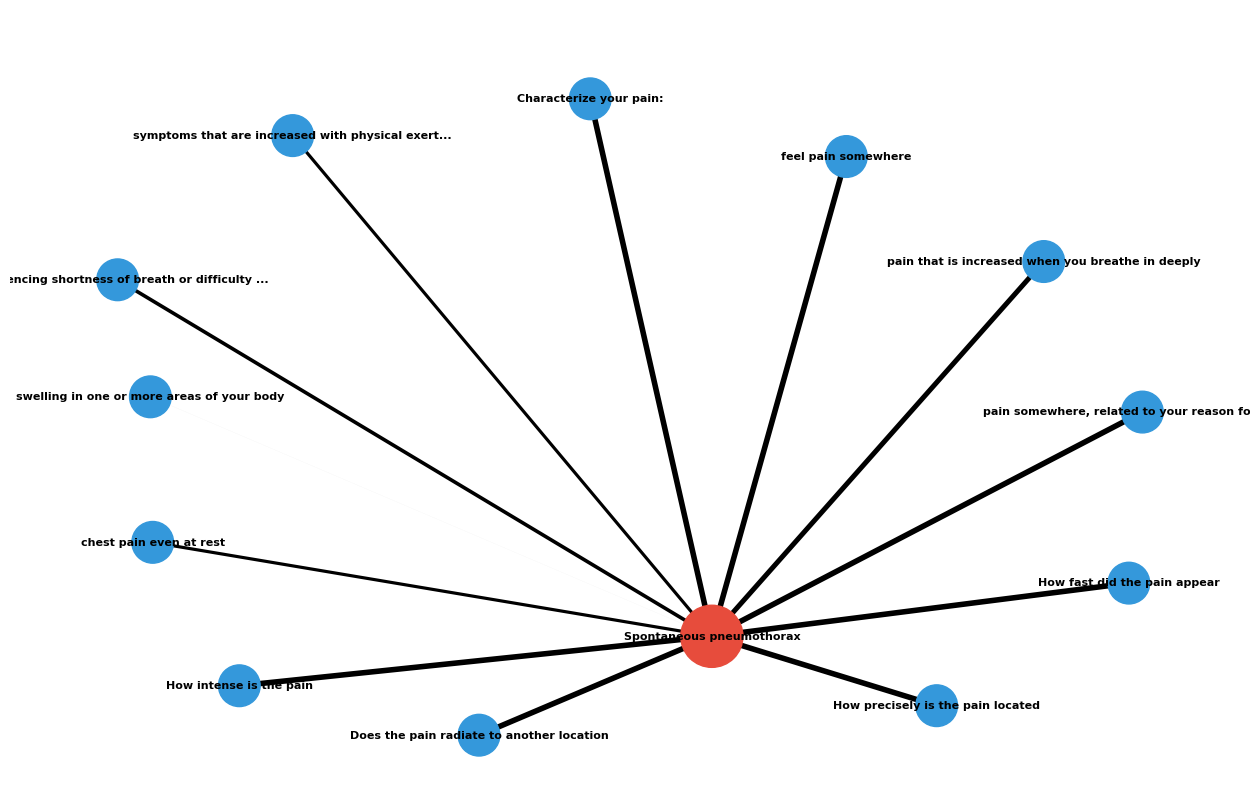

In [9]:
example_diagnosis = list(conditions.keys())[0]
neighbor_nodes = list(G.neighbors(example_diagnosis))[:12]
sub = G.subgraph([example_diagnosis] + neighbor_nodes)

fig, ax = plt.subplots(figsize=(16, 10))
pos = nx.spring_layout(sub, seed=42, k=3)

node_color_map = {
    "diagnosis":  "#e74c3c",
    "symptom":    "#3498db",
    "antecedent": "#2ecc71",
    "procedure":  "#f39c12",
}
colors = [node_color_map.get(G.nodes[n].get("node_type"), "#95a5a6") for n in sub.nodes()]
sizes  = [2000 if G.nodes[n].get("node_type") == "diagnosis" else 900 for n in sub.nodes()]
edge_weights = [sub[u][v]["weight"] * 4 for u, v in sub.edges()]

nx.draw(sub, pos, ax=ax,
        node_color=colors,
        node_size=sizes,
        width=edge_weights,
        with_labels=True,
        font_size=8,
        font_weight="bold")

ax.set_title(f"Граф знань: «{example_diagnosis}»  "
             f"(діагноз / симптом / антецедент / процедура)", fontsize=13)
fig.savefig("graph_sample.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
import pickle

with open("knowledge_graph.pkl", "wb") as f:
    pickle.dump(G, f)

print("knowledge_graph.pkl збережено")


knowledge_graph.pkl збережено
